# PunePulse — Forecasting Experiments
**Model 1: Hourly Footfall Forecast**

This notebook builds the demand forecasting model end-to-end.
Every concept is explained at the point where it appears.

| Stage | What you learn |
|---|---|
| Feature engineering | Cyclical encoding, lag features, one-hot encoding |
| Train/test split | Why time-series data can't use random splits |
| XGBoost | Why gradient boosting beats linear models for this problem |
| Evaluation | MAE, RMSE, R² — what each one tells you |
| Prediction | How to construct tomorrow's feature row |
| Saving | How the model moves from notebook to dashboard |

---
## 0. Setup

Install the two new packages this notebook needs:
```
pip install xgboost scikit-learn joblib
```
`xgboost` — the model we train  
`scikit-learn` — train/test splitting, metrics, cross-validation  
`joblib` — saves the trained model to disk so the dashboard can load it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import os
import warnings

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs/charts', exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Load & Merge

We need two things in the same table:
- **Time-series signals** from `synthetic_footfall.csv` — one row per restaurant per hour
- **Static restaurant attributes** from `restaurants_cleaned.csv` — locality, cuisine, price_range

### Why merge?
The model needs to know *who* is experiencing demand, not just *how much* demand. A Hinjewadi IT-park restaurant has a completely different hourly profile than a Kothrud residential one. Locality and cuisine are the features that let the model learn those differences.

### How: `pd.merge()` with `how='left'`
A left merge keeps every row from the left table (footfall) and attaches matching columns from the right table (restaurants). If a restaurant in footfall has no match in restaurants_cleaned, its new columns get NaN — you'll see this in the check below.

In [2]:
footfall    = pd.read_csv('C:\\Users\\chari\\OneDrive\\Desktop\\Projects\\Pune Restaurant Demand Intelligence Platform\\data\\cleaned\\synthetic_footfall.csv')
restaurants = pd.read_csv('C:\\Users\\chari\\OneDrive\\Desktop\\Projects\\Pune Restaurant Demand Intelligence Platform\\data\\cleaned\\restaurants_cleaned.csv')

# Parse dates immediately — needed for time-series operations later
footfall['date'] = pd.to_datetime(footfall['date'])

print('Footfall shape    :', footfall.shape)
print('Restaurants shape :', restaurants.shape)
print('\nFootfall columns  :', footfall.columns.tolist())
print('Restaurant columns:', restaurants.columns.tolist())

Footfall shape    : (87840, 11)
Restaurants shape : (455, 15)

Footfall columns  : ['restaurant_name', 'locality', 'cuisine', 'date', 'hour', 'footfall', 'is_weekend', 'month', 'is_monsoon', 'festival', 'day_of_week']
Restaurant columns: ['place_id', 'restaurant_name', 'locality', 'address', 'lat', 'lon', 'rating', 'review_count', 'price_range', 'business_tags', 'opening_hours', 'business_status', 'price_range_missing', 'business_type', 'cuisine_type']


In [3]:
# Merge on restaurant_name
# We only need a few static columns from restaurants — avoid column explosion
static_cols = ['restaurant_name', 'locality', 'cuisine_type', 'price_range', 'rating']

# Keep only the static columns that actually exist in restaurants_cleaned
static_cols = [c for c in static_cols if c in restaurants.columns]
print('Static columns available:', static_cols)

df = footfall.merge(
    restaurants[static_cols],
    on='restaurant_name',
    how='left'
)

print('\nMerged shape:', df.shape)

# Sanity check: how many rows lost their locality after merge?
missing_locality = df['locality'].isna().sum() if 'locality' in df.columns else 'locality not in df'
print('Rows with missing locality after merge:', missing_locality)

Static columns available: ['restaurant_name', 'locality', 'cuisine_type', 'price_range', 'rating']

Merged shape: (87840, 15)
Rows with missing locality after merge: locality not in df


In [4]:
# If locality is missing for some rows, fill with what footfall already has
# (synthetic_footfall.csv already has a locality column)
if 'locality_x' in df.columns:      # merge created locality_x, locality_y
    df['locality'] = df['locality_x'].fillna(df['locality_y'])
    df.drop(columns=['locality_x', 'locality_y'], inplace=True)

print('Columns after merge cleanup:', df.columns.tolist())
df.head(3)

Columns after merge cleanup: ['restaurant_name', 'cuisine', 'date', 'hour', 'footfall', 'is_weekend', 'month', 'is_monsoon', 'festival', 'day_of_week', 'cuisine_type', 'price_range', 'rating', 'locality']


,restaurant_name,cuisine,date,hour,footfall,is_weekend,month,is_monsoon,festival,day_of_week,cuisine_type,price_range,rating,locality
0,Vaishali,South Indian,2024-01-01,0,0,0,1,0,none,Monday,Unknown,Unknown,3.7,FC Road
1,Vaishali,South Indian,2024-01-01,1,0,0,1,0,none,Monday,Unknown,Unknown,3.7,FC Road
2,Vaishali,South Indian,2024-01-01,2,0,0,1,0,none,Monday,Unknown,Unknown,3.7,FC Road


---
## 2. Feature Engineering

This is the most important section. **Feature engineering is where ML models are won or lost.** Raw columns are rarely in the right form for a model to learn from. We need to transform them.

We'll build 5 types of features:
1. **Cyclical encoding** — for `hour` and `month`
2. **Calendar flags** — `is_weekend`, `is_monsoon`
3. **Categorical encoding** — `locality`, `festival`, `cuisine_type`
4. **Lag features** — what footfall was 7 days ago at this hour
5. **Static numerics** — `rating`, `price_range` (already numeric or will be mapped)

### 2.1 Cyclical Encoding — Why Not Just Use the Number?

If you give the model `hour=23` and `hour=0`, it sees them as far apart (distance 23). But 11pm and midnight are one hour apart — they should be *similar* to the model.

The fix: encode hour as a point on a circle using **sine and cosine**.
- `hour_sin = sin(2π × hour / 24)`
- `hour_cos = cos(2π × hour / 24)`

Now hour 23 and hour 0 are very close in (sin, cos) space. The model learns the circular pattern correctly. Same logic applies to `month`.

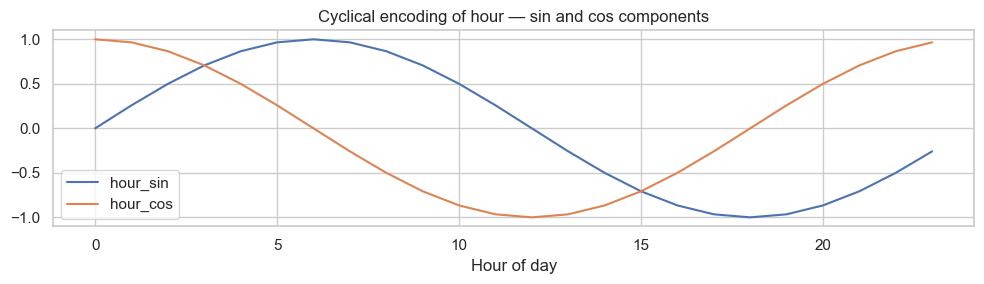

Cyclical features created.


In [5]:
# ── 2.1 Cyclical encoding ─────────────────────────────────────────────

# Hour: 24-hour cycle
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Month: 12-month cycle
df['month']     = df['date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day of year: useful for capturing gradual seasonal trends
df['day_of_year'] = df['date'].dt.dayofyear

# Quick visual to confirm cyclical encoding is correct
hours = np.arange(24)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(hours, np.sin(2 * np.pi * hours / 24), label='hour_sin')
ax.plot(hours, np.cos(2 * np.pi * hours / 24), label='hour_cos')
ax.set_xlabel('Hour of day')
ax.set_title('Cyclical encoding of hour — sin and cos components', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print('Cyclical features created.')

In [6]:
# ── 2.2 Calendar flags (already exist in footfall, just confirm) ──────

# is_weekend: 1 if Saturday or Sunday, else 0
# is_monsoon: 1 if June–September, else 0
# These should already be in synthetic_footfall — verify:

print('is_weekend present:', 'is_weekend' in df.columns)
print('is_monsoon present:', 'is_monsoon' in df.columns)

# If they are missing, create them:
if 'is_weekend' not in df.columns:
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    print('  Created is_weekend')

if 'is_monsoon' not in df.columns:
    df['is_monsoon'] = df['month'].between(6, 9).astype(int)
    print('  Created is_monsoon')

print('\nValue counts — is_weekend:')
print(df['is_weekend'].value_counts())

is_weekend present: True
is_monsoon present: True

Value counts — is_weekend:
is_weekend
0    62880
1    24960
Name: count, dtype: int64


In [7]:
# ── 2.3 Categorical encoding ──────────────────────────────────────────
#
# ML models work with numbers, not strings.
# We convert string categories to numeric using one-hot encoding:
# 'Baner' becomes [1, 0, 0, 0, 0, 0, 0, 0]
# 'Kothrud' becomes [0, 0, 1, 0, 0, 0, 0, 0]
# etc.
#
# drop_first=True removes one column to avoid the 'dummy variable trap'
# (perfect multicollinearity: if all others are 0, this locality is implied)

# Fill missing categoricals before encoding
if 'locality' in df.columns:
    df['locality'] = df['locality'].fillna('Unknown')
if 'cuisine_type' in df.columns:
    df['cuisine_type'] = df['cuisine_type'].fillna('Unknown')
if 'festival' in df.columns:
    df['festival'] = df['festival'].fillna('None')

# Which columns to one-hot encode
cat_cols = [c for c in ['locality', 'cuisine_type', 'festival'] if c in df.columns]
print('Columns to one-hot encode:', cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('Shape after one-hot encoding:', df.shape)

Columns to one-hot encode: ['locality', 'cuisine_type', 'festival']
Shape after one-hot encoding: (87840, 28)


In [8]:
# ── 2.4 Lag features ──────────────────────────────────────────────────
#
# A lag feature answers: "what was footfall exactly 7 days ago at this hour?"
# This is the single most powerful feature for demand forecasting.
# Why? Because last week Thursday 9pm is the best predictor of this week Thursday 9pm.
#
# How shift() works:
# df['footfall'].shift(N) moves every value down by N rows.
# The first N rows get NaN (no history yet).
#
# CRITICAL: we must sort by (restaurant_name, date, hour) before shifting.
# If rows are not sorted, we shift across the wrong rows.

df.sort_values(['restaurant_name', 'date', 'hour'], inplace=True)
df.reset_index(drop=True, inplace=True)

# One day = 24 hours. Seven days = 168 rows per restaurant.
HOURS_PER_DAY  = 24
HOURS_7_DAYS   = 7  * HOURS_PER_DAY   # 168
HOURS_14_DAYS  = 14 * HOURS_PER_DAY   # 336

# Lag within each restaurant separately using groupby + shift
# This prevents lag bleeding across restaurant boundaries
grp = df.groupby('restaurant_name')['footfall']

df['lag_7d']  = grp.shift(HOURS_7_DAYS)
df['lag_14d'] = grp.shift(HOURS_14_DAYS)

# Rolling mean: average footfall over the previous 7 days at this same hour
# min_periods=1 avoids NaN for the first few rows
df['rolling_7d_mean'] = (
    grp
    .transform(lambda x: x.shift(HOURS_7_DAYS).rolling(HOURS_7_DAYS, min_periods=1).mean())
)

print('Lag features created.')
print('NaN counts from lags:')
print(df[['lag_7d', 'lag_14d', 'rolling_7d_mean']].isna().sum())

Lag features created.
NaN counts from lags:
lag_7d             1680
lag_14d            3360
rolling_7d_mean    1680
dtype: int64


In [9]:
# ── 2.5 Price range as numeric ────────────────────────────────────────
#
# price_range is stored as strings like '$', '$$', '$$$'.
# Map to integers 1, 2, 3, 4 so the model can use it numerically.

if 'price_range' in df.columns:
    price_map = {'$': 1, '$$': 2, '$$$': 3, '$$$$': 4}
    df['price_range_num'] = df['price_range'].map(price_map).fillna(2)  # default = mid-range
    print('price_range_num created. Value counts:')
    print(df['price_range_num'].value_counts().sort_index())
else:
    df['price_range_num'] = 2  # default if column missing
    print('price_range column not found — defaulting to 2')

# Fill any remaining numeric NaNs with column median
if 'rating' in df.columns:
    df['rating'] = df['rating'].fillna(df['rating'].median())

price_range_num created. Value counts:
price_range_num
2.0    87840
Name: count, dtype: int64


---
## 3. Define Features and Target

The **target** (`y`) is what we want to predict: `footfall`.

The **features** (`X`) are every column we feed to the model. We explicitly list them to:
- avoid accidentally feeding the model the target itself
- avoid feeding string columns the model can't process
- have a clear record of exactly what the model was trained on (important when loading it in the dashboard)

In [10]:
TARGET = 'footfall'

# ── Base numeric/binary features ─────────────────────────────────────
base_features = [
    'hour',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'day_of_year',
    'is_weekend',
    'is_monsoon',
    'price_range_num',
]

# Add rating if available
if 'rating' in df.columns:
    base_features.append('rating')

# Add lag features
lag_features = ['lag_7d', 'lag_14d', 'rolling_7d_mean']

# ── One-hot encoded columns ───────────────────────────────────────────
# These were created by pd.get_dummies() — they all start with the
# original column name followed by '_'
ohe_features = [
    c for c in df.columns
    if c.startswith('locality_')
    or c.startswith('cuisine_type_')
    or c.startswith('festival_')
]

# Combine all features
ALL_FEATURES = base_features + lag_features + ohe_features

# Verify every feature actually exists in df
missing = [f for f in ALL_FEATURES if f not in df.columns]
if missing:
    print('WARNING — these features are missing from df:', missing)
    ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Total features: {len(ALL_FEATURES)}')
print('\nFeature list:')
for f in ALL_FEATURES:
    print(' ', f)

Total features: 25

Feature list:
  hour
  hour_sin
  hour_cos
  month_sin
  month_cos
  day_of_year
  is_weekend
  is_monsoon
  price_range_num
  rating
  lag_7d
  lag_14d
  rolling_7d_mean
  locality_Baner
  locality_Camp
  locality_FC Road
  locality_Hadapsar
  locality_Hinjewadi
  locality_Koregaon Park
  locality_Kothrud
  locality_Shivajinagar
  festival_Ganesh Chaturthi
  festival_Gudi Padwa
  festival_New Year Eve
  festival_none


---
## 4. Train / Test Split — Time-Series Style

### Why NOT `train_test_split(random_state=42)`?

In most ML tutorials, you randomly shuffle rows into train and test. **This is wrong for time-series data.**

If you randomly split, your training set will contain rows from December, and your test set will contain rows from March. The model sees December data and learns patterns from the future. When it then 'predicts' March, it's cheating — it already learned from data that came after March. This is called **data leakage**, and it makes your evaluation metrics look far better than they really are.

**The correct approach:** train on the past, test on the future.
- Train: Jan–Oct 2024 (10 months)
- Test: Nov–Dec 2024 (2 months, truly unseen)

This simulates exactly what happens in production: the model is trained on historical data, and you evaluate it on future data it has never seen.

In [11]:
# Drop rows where lag features are NaN
# (first 7 days of each restaurant have no 7-day lag)
df_model = df.dropna(subset=['lag_7d', 'lag_14d', 'rolling_7d_mean']).copy()
print(f'Rows after dropping lag NaNs: {len(df_model):,} (was {len(df):,})')

# ── Temporal split ────────────────────────────────────────────────────
SPLIT_DATE = '2024-11-01'   # train < this date, test >= this date

train = df_model[df_model['date'] < SPLIT_DATE].copy()
test  = df_model[df_model['date'] >= SPLIT_DATE].copy()

print(f'\nTrain: {len(train):,} rows  ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Test:  {len(test):,} rows  ({test["date"].min().date()} → {test["date"].max().date()})')

X_train = train[ALL_FEATURES]
y_train = train[TARGET]

X_test  = test[ALL_FEATURES]
y_test  = test[TARGET]

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

Rows after dropping lag NaNs: 84,480 (was 87,840)

Train: 69,840 rows  (2024-01-15 → 2024-10-31)
Test:  14,640 rows  (2024-11-01 → 2024-12-31)

X_train shape: (69840, 25)
X_test shape:  (14640, 25)


---
## 5. Train the Model — XGBoost

### What is XGBoost?

XGBoost (Extreme Gradient Boosting) builds an ensemble of decision trees sequentially. Each tree is trained to fix the errors of the previous trees. After hundreds of trees, the ensemble is very powerful.

It works well for this problem because:
- It handles mixed feature types (numeric, binary, one-hot) without scaling
- It captures non-linear interactions (e.g. festival × weekend is a spike, not just additive)
- It's robust to outliers
- It's the industry standard for tabular demand forecasting

### Key hyperparameters explained:
- `n_estimators` — number of trees. More trees = more accurate but slower. Start with 500.
- `learning_rate` — how much each tree contributes. Lower = more conservative. 0.05 is a good default.
- `max_depth` — how deep each tree can grow. Deeper = more complex patterns but risk of overfitting. 6 is standard.
- `subsample` — fraction of training rows each tree sees. 0.8 = 80% of rows, adds randomness = less overfitting.
- `colsample_bytree` — fraction of features each tree sees. Same idea.
- `early_stopping_rounds` — stop training if test score doesn't improve for N rounds. Prevents overfitting.

In [12]:
model = XGBRegressor(
    n_estimators       = 500,
    learning_rate      = 0.05,
    max_depth          = 6,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    random_state       = 42,
    n_jobs             = -1,     # use all CPU cores
    early_stopping_rounds = 30,  # stop if no improvement for 30 rounds
    eval_metric        = 'mae',  # monitor MAE during training
)

print('Training XGBoost model...')

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],   # monitor performance on test set during training
    verbose=50                     # print progress every 50 rounds
)

print('\nTraining complete.')
print(f'Best iteration: {model.best_iteration}')

Training XGBoost model...
[0]	validation_0-mae:4.10167
[50]	validation_0-mae:1.47704
[100]	validation_0-mae:1.39974
[150]	validation_0-mae:1.38492
[200]	validation_0-mae:1.38051
[250]	validation_0-mae:1.37865
[273]	validation_0-mae:1.38342

Training complete.
Best iteration: 243


---
## 6. Evaluate

### Three metrics — what each one tells you:

**MAE (Mean Absolute Error):** Average absolute difference between predicted and actual. If MAE = 5, predictions are off by 5 visitors on average. *Most interpretable — same unit as footfall.*

**RMSE (Root Mean Squared Error):** Like MAE but penalises large errors more heavily (due to squaring). If RMSE >> MAE, you have occasional very large errors. *Good for catching outlier predictions.*

**R² (Coefficient of Determination):** How much variance in footfall does the model explain? 1.0 = perfect, 0.0 = no better than predicting the mean, negative = worse than predicting the mean. *A score of 0.85+ is solid for this type of problem.*

In [13]:
# ── Predictions on test set ───────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Metrics ───────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('MODEL EVALUATION — Test Set (Nov–Dec 2024)')
print('=' * 45)
print(f'MAE  (avg error in footfall units) : {mae:.2f}')
print(f'RMSE (penalises large errors more) : {rmse:.2f}')
print(f'R²   (variance explained, 0–1)    : {r2:.4f}')

# Contextualise MAE against actual footfall scale
mean_actual = y_test.mean()
print(f'\nMean actual footfall (test) : {mean_actual:.1f}')
print(f'MAE as % of mean            : {mae / mean_actual * 100:.1f}%')
print('\nInterpretation:')
if mae / mean_actual < 0.10:
    print('  Excellent — error is < 10% of mean footfall')
elif mae / mean_actual < 0.20:
    print('  Good — error is 10–20% of mean footfall')
else:
    print('  Review features — error is > 20% of mean footfall')

MODEL EVALUATION — Test Set (Nov–Dec 2024)
MAE  (avg error in footfall units) : 1.38
RMSE (penalises large errors more) : 2.52
R²   (variance explained, 0–1)    : 0.7993

Mean actual footfall (test) : 4.3
MAE as % of mean            : 31.8%

Interpretation:
  Review features — error is > 20% of mean footfall


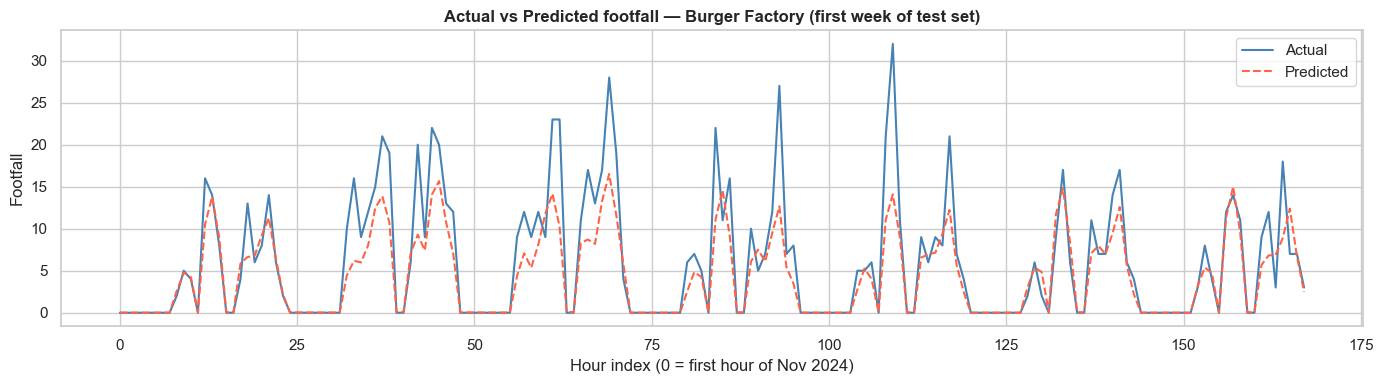

In [14]:
# ── Actual vs Predicted plot ──────────────────────────────────────────
#
# Plot one week of predictions vs actuals for one restaurant.
# This is far more informative than metrics alone — you can see
# where the model over/under-predicts.

sample_restaurant = test['restaurant_name'].iloc[0]
mask = test['restaurant_name'] == sample_restaurant

sample_test  = test[mask].copy()
sample_pred  = y_pred[mask.values]

# One week of data
sample_test  = sample_test.head(7 * 24)
sample_pred  = sample_pred[:7 * 24]

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(range(len(sample_test)), sample_test[TARGET].values,
        label='Actual', color='steelblue', linewidth=1.5)
ax.plot(range(len(sample_test)), sample_pred,
        label='Predicted', color='tomato', linewidth=1.5, linestyle='--')

ax.set_title(f'Actual vs Predicted footfall — {sample_restaurant} (first week of test set)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Hour index (0 = first hour of Nov 2024)')
ax.set_ylabel('Footfall')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/charts/model1_actual_vs_predicted.png', dpi=150)
plt.show()

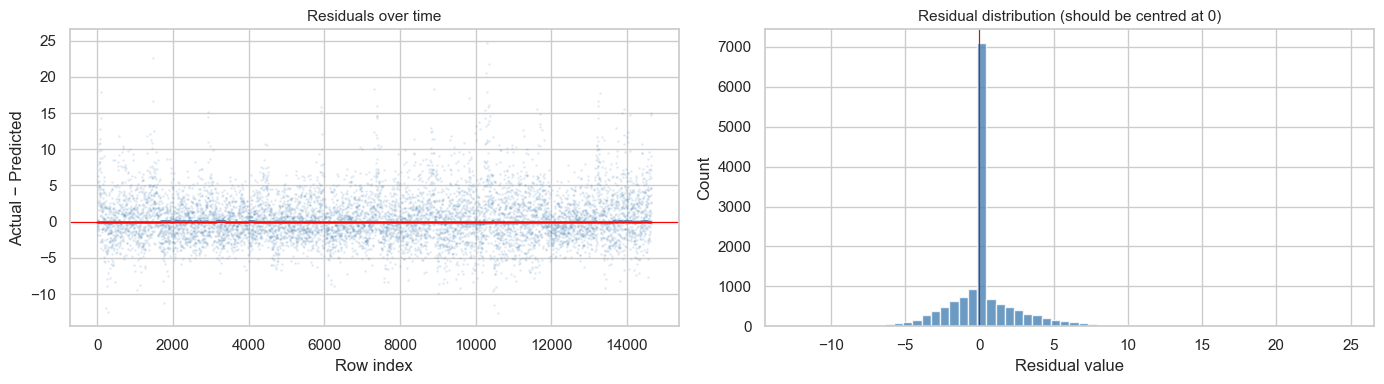

If residuals are centred at 0 with no strong pattern, the model is unbiased.
If they skew positive, the model systematically under-predicts.
If they skew negative, it over-predicts.


In [15]:
# ── Residuals plot ────────────────────────────────────────────────────
#
# Residual = actual - predicted
# A good model has residuals randomly scattered around 0.
# Patterns in residuals = the model is systematically wrong about something.

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals over time
axes[0].scatter(range(len(residuals)), residuals, alpha=0.1, s=1, color='steelblue')
axes[0].axhline(0, color='red', linewidth=0.8)
axes[0].set_title('Residuals over time', fontsize=11)
axes[0].set_xlabel('Row index')
axes[0].set_ylabel('Actual − Predicted')

# Residual distribution
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=0.8)
axes[1].set_title('Residual distribution (should be centred at 0)', fontsize=11)
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/charts/model1_residuals.png', dpi=150)
plt.show()

print('If residuals are centred at 0 with no strong pattern, the model is unbiased.')
print('If they skew positive, the model systematically under-predicts.')
print('If they skew negative, it over-predicts.')

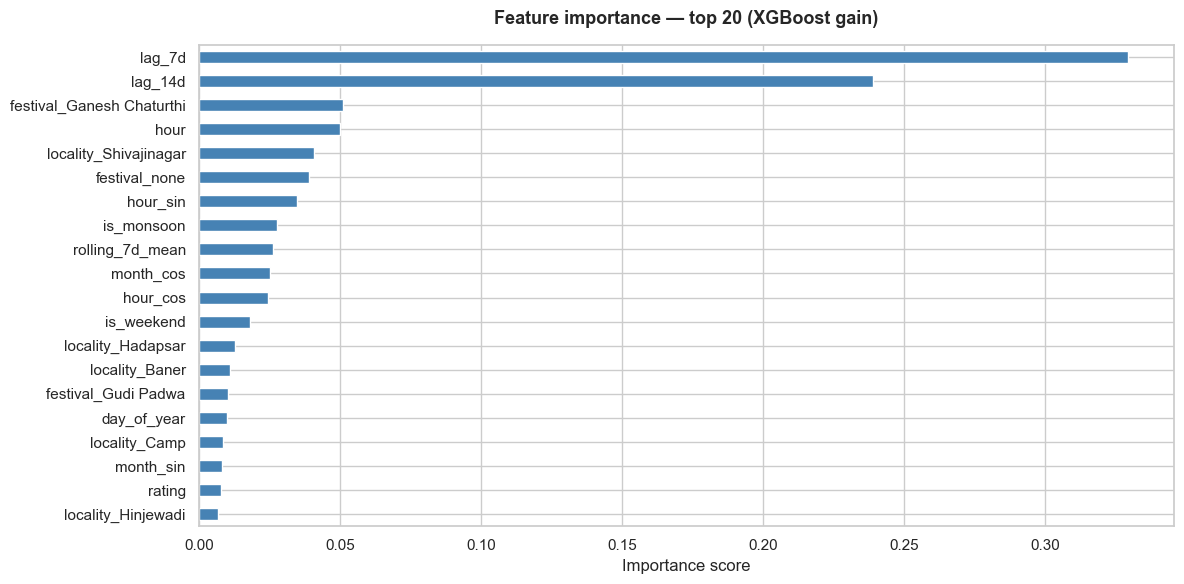

Top 5 features:
lag_7d                       0.329371
lag_14d                      0.238980
festival_Ganesh Chaturthi    0.051075
hour                         0.050117
locality_Shivajinagar        0.040770
dtype: float32


In [16]:
# ── Feature importance ────────────────────────────────────────────────
#
# XGBoost tracks how often each feature was used in splits across all trees,
# and how much each split improved predictions.
# This tells you which features are actually driving the model's decisions.
#
# Expected: lag_7d, hour, rolling_7d_mean should be top features.
# If festival or locality features rank high, your encoding worked.

importance = pd.Series(
    model.feature_importances_,
    index=ALL_FEATURES
).sort_values(ascending=False)

# Show top 20
top_features = importance.head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature importance — top 20 (XGBoost gain)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importance score')

plt.tight_layout()
plt.savefig('../outputs/charts/model1_feature_importance.png', dpi=150)
plt.show()

print('Top 5 features:')
print(importance.head())

---
## 7. Time-Series Cross-Validation

A single train/test split gives you one estimate of performance. Cross-validation gives you several.

### TimeSeriesSplit — how it works:
Instead of randomly shuffling, it creates multiple train/test windows that always respect time order:
- Fold 1: train Jan–Mar, test Apr
- Fold 2: train Jan–Jun, test Jul
- Fold 3: train Jan–Sep, test Oct
- etc.

The training window always ends before the test window starts. No data leakage.

The MAE across all folds tells you how consistent the model is — a low average with low variance means it performs reliably across different time periods.

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

X_all = df_model[ALL_FEATURES]
y_all = df_model[TARGET]

fold_scores = []

print('Running TimeSeriesSplit cross-validation...')

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all), start=1):

    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]

    # Quick model per fold (fewer trees to keep it fast)
    fold_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    fold_model.fit(X_tr, y_tr, verbose=False)
    preds = fold_model.predict(X_val)

    fold_mae = mean_absolute_error(y_val, preds)
    fold_r2  = r2_score(y_val, preds)
    fold_scores.append({'fold': fold, 'MAE': fold_mae, 'R2': fold_r2,
                        'train_size': len(X_tr), 'val_size': len(X_val)})

    print(f'  Fold {fold}: MAE={fold_mae:.2f}  R²={fold_r2:.4f}  '
          f'(train={len(X_tr):,} val={len(X_val):,})')

scores_df = pd.DataFrame(fold_scores)
print(f'\nMean MAE across folds: {scores_df["MAE"].mean():.2f} ± {scores_df["MAE"].std():.2f}')
print(f'Mean R²  across folds: {scores_df["R2"].mean():.4f} ± {scores_df["R2"].std():.4f}')

Running TimeSeriesSplit cross-validation...
  Fold 1: MAE=1.15  R²=0.6148  (train=14,080 val=14,080)
  Fold 2: MAE=0.99  R²=0.7494  (train=28,160 val=14,080)
  Fold 3: MAE=1.17  R²=0.7589  (train=42,240 val=14,080)
  Fold 4: MAE=1.59  R²=0.7620  (train=56,320 val=14,080)
  Fold 5: MAE=1.10  R²=0.7892  (train=70,400 val=14,080)

Mean MAE across folds: 1.20 ± 0.23
Mean R²  across folds: 0.7349 ± 0.0687


---
## 8. Predict Tomorrow

This is the function that powers the dashboard. Given a restaurant name and a date, it builds the feature row for every hour of that day and returns predicted footfall per hour.

### The key insight: feature row construction
The model was trained on rows with specific features. When you predict, you must provide exactly the same features, in the same order. This is why we saved `ALL_FEATURES` — it guarantees consistency between training and prediction.

In [18]:
def predict_tomorrow(restaurant_name, target_date, model, all_features, historical_df):
    """
    Predict hourly footfall for a restaurant on a given date.

    Parameters
    ----------
    restaurant_name : str
        Must match a name in historical_df.
    target_date : str or datetime
        The date to predict. e.g. '2025-01-01'
    model : trained XGBRegressor
    all_features : list of str
        Exact feature list used during training.
    historical_df : pd.DataFrame
        The full processed dataframe — needed to compute lag features.

    Returns
    -------
    pd.DataFrame with columns: hour, predicted_footfall
    """

    target_date = pd.Timestamp(target_date)

    # Get restaurant's historical data for lag computation
    rest_history = historical_df[
        historical_df['restaurant_name'] == restaurant_name
    ].sort_values(['date', 'hour'])

    if len(rest_history) == 0:
        raise ValueError(f'Restaurant "{restaurant_name}" not found in historical data.')

    results = []

    for hour in range(24):

        # ── Build one feature row ──────────────────────────────────────
        row = {}

        # Temporal features
        row['hour']        = hour
        row['hour_sin']    = np.sin(2 * np.pi * hour / 24)
        row['hour_cos']    = np.cos(2 * np.pi * hour / 24)
        row['month_sin']   = np.sin(2 * np.pi * target_date.month / 12)
        row['month_cos']   = np.cos(2 * np.pi * target_date.month / 12)
        row['day_of_year'] = target_date.day_of_year
        row['is_weekend']  = int(target_date.dayofweek >= 5)
        row['is_monsoon']  = int(target_date.month in [6, 7, 8, 9])

        # Lag features: look up actual historical footfall
        date_7d_ago  = target_date - pd.Timedelta(days=7)
        date_14d_ago = target_date - pd.Timedelta(days=14)

        lag7_row = rest_history[
            (rest_history['date'] == date_7d_ago) &
            (rest_history['hour'] == hour)
        ]
        lag14_row = rest_history[
            (rest_history['date'] == date_14d_ago) &
            (rest_history['hour'] == hour)
        ]

        row['lag_7d']  = lag7_row['footfall'].values[0] if len(lag7_row) > 0 else rest_history['footfall'].mean()
        row['lag_14d'] = lag14_row['footfall'].values[0] if len(lag14_row) > 0 else rest_history['footfall'].mean()

        # Rolling mean: average footfall at this hour over past 7 days
        past_7d = rest_history[
            (rest_history['date'] >= date_7d_ago) &
            (rest_history['date'] < target_date) &
            (rest_history['hour'] == hour)
        ]
        row['rolling_7d_mean'] = past_7d['footfall'].mean() if len(past_7d) > 0 else row['lag_7d']

        # Static features from restaurant profile
        rest_row = rest_history.iloc[0]
        row['price_range_num'] = rest_row.get('price_range_num', 2)
        if 'rating' in rest_row.index:
            row['rating'] = rest_row['rating']

        # One-hot encoded features: all start at 0, set the right ones to 1
        for col in all_features:
            if col not in row:
                row[col] = 0  # default 0 for all OHE columns

        # Set the correct locality OHE column
        if 'locality' in rest_row.index:
            ohe_col = f'locality_{rest_row["locality"]}'
            if ohe_col in all_features:
                row[ohe_col] = 1

        # ── Predict ───────────────────────────────────────────────────
        X_row = pd.DataFrame([row])[all_features]  # enforce column order
        prediction = model.predict(X_row)[0]
        prediction = max(0, prediction)  # footfall can't be negative

        results.append({'hour': hour, 'predicted_footfall': round(prediction, 1)})

    return pd.DataFrame(results)


print('predict_tomorrow() function defined.')

predict_tomorrow() function defined.


Forecast for: Burger Factory
Date: 2024-12-15
    hour  predicted_footfall
0      0            0.000000
1      1            0.000000
2      2            0.000000
3      3            0.000000
4      4            0.000000
5      5            0.000000
6      6            0.000000
7      7            0.000000
8      8            4.300000
9      9            8.200000
10    10            5.900000
11    11            7.900000
12    12           15.000000
13    13           17.500000
14    14           11.100000
15    15            0.100000
16    16            0.100000
17    17           10.700000
18    18           14.300000
19    19           10.800000
20    20           17.200001
21    21           19.500000
22    22           12.800000
23    23            5.500000


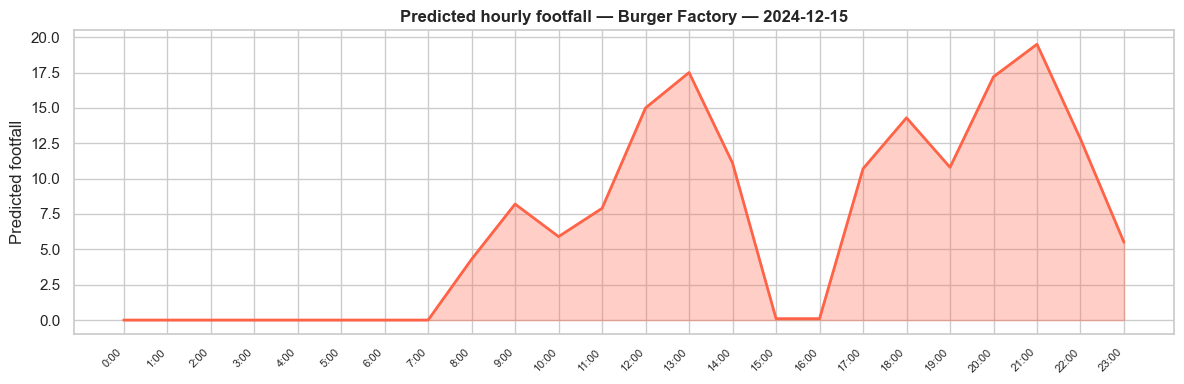

In [19]:
# ── Test the prediction function ──────────────────────────────────────
sample_name = df_model['restaurant_name'].iloc[0]
tomorrow    = '2024-12-15'

forecast = predict_tomorrow(
    restaurant_name = sample_name,
    target_date     = tomorrow,
    model           = model,
    all_features    = ALL_FEATURES,
    historical_df   = df_model
)

print(f'Forecast for: {sample_name}')
print(f'Date: {tomorrow}')
print(forecast)

# Quick visualisation
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(forecast['hour'], forecast['predicted_footfall'], alpha=0.3, color='tomato')
ax.plot(forecast['hour'], forecast['predicted_footfall'], color='tomato', linewidth=2)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_title(f'Predicted hourly footfall — {sample_name} — {tomorrow}', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted footfall')
plt.tight_layout()
plt.savefig('../outputs/charts/model1_sample_forecast.png', dpi=150)
plt.show()

---
## 9. Save the Model

We save two things:
1. **The trained model** (`footfall_model.pkl`) — the XGBoost object with all its learned parameters
2. **The feature list** (`footfall_features.pkl`) — the exact list of features and their order

Why save the feature list separately? When the dashboard loads the model and calls `model.predict(X)`, `X` must have exactly the same columns in exactly the same order as when the model was trained. Saving the feature list eliminates any guesswork.

In [20]:
MODEL_PATH    = '../models/footfall_model.pkl'
FEATURES_PATH = '../models/footfall_features.pkl'

joblib.dump(model,        MODEL_PATH)
joblib.dump(ALL_FEATURES, FEATURES_PATH)

print(f'Model saved to    : {MODEL_PATH}')
print(f'Features saved to : {FEATURES_PATH}')

# Verify: reload and check it still works
loaded_model    = joblib.load(MODEL_PATH)
loaded_features = joblib.load(FEATURES_PATH)

reload_preds = loaded_model.predict(X_test[loaded_features])
reload_mae   = mean_absolute_error(y_test, reload_preds)
print(f'\nVerification — MAE from reloaded model: {reload_mae:.2f} (should match original)')

Model saved to    : ../models/footfall_model.pkl
Features saved to : ../models/footfall_features.pkl

Verification — MAE from reloaded model: 1.38 (should match original)


---
## 10. Summary & Next Steps

You've built a complete ML forecasting pipeline:
- Merged footfall with restaurant attributes
- Engineered cyclical, lag, and categorical features
- Split correctly for time-series
- Trained and cross-validated XGBoost
- Evaluated with MAE, RMSE, R², residuals, and feature importance
- Built a `predict_tomorrow()` function
- Saved model + feature list to `models/`

---

### Models 2, 3, and 4 follow the same pattern

| Model | Target column | Key difference |
|---|---|---|
| Model 2 — order volume | `n_items` (from synthetic_orders) | Use orders df, not footfall |
| Model 3 — peak hour classifier | Binary: is this a rush hour? | Change to XGBClassifier, use F1 score |
| Model 4 — revenue estimator | `order_value_inr` | Regression, same pipeline |

### What the dashboard will do with `models/footfall_model.pkl`
```python
import joblib
model    = joblib.load('models/footfall_model.pkl')
features = joblib.load('models/footfall_features.pkl')
# build X_tomorrow with same feature engineering
forecast = model.predict(X_tomorrow[features])
```
The dashboard calls this at page load, renders the hourly chart, and derives the inventory and staffing alerts from the predicted values.